In [1]:
import scanpy as sc
import spatialdata as sd
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sdata_1D = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_1D_annotated.zarr')
adata_1D = sdata_1D.tables["Baysor"]
sdata_1H = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_1H_annotated.zarr')
adata_1H = sdata_1H.tables["Baysor"]
sdata_2D = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_2D_annotated.zarr')
adata_2D = sdata_2D.tables["Baysor"]
sdata_2H = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_2H_annotated.zarr')
adata_2H = sdata_2H.tables["Baysor"]
sdata_3D = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_3D_annotated.zarr')
adata_3D = sdata_3D.tables["Baysor"]
sdata_3H = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_3H_annotated.zarr')
adata_3H = sdata_3H.tables["Baysor"]
sdata_4D = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_4D_annotated.zarr')
adata_4D = sdata_4D.tables["Baysor"]
sdata_4H = sd.read_zarr('Version 2 Baysor cell type Zarr//Sample_4H_annotated.zarr')
adata_4H = sdata_4H.tables["Baysor"]

In [3]:
adata_all_samples = adata_1D.concatenate(adata_1H, adata_2D, adata_2H, adata_3D, adata_3H, adata_4D, adata_4H)
adata_all_samples

C:\Users\laure\AppData\Local\Temp\ipykernel_23512\1013547174.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all_samples = adata_1D.concatenate(adata_1H, adata_2D, adata_2H, adata_3D, adata_3H, adata_4D, adata_4H)


AnnData object with n_obs × n_vars = 124799 × 344
    obs: 'cell', 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'plaque_region', 'sample', 'donor', 'condition', 'n_counts', 'leiden', 'cell_type', 'batch'
    var: 'gene_ids', 'feature_types'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [4]:
adata_all_samples.write_h5ad("Version 2 Baysor cell type Zarr//All_samples_annotated.h5ad")

In [2]:
adata = sc.read_h5ad("Version 2 Baysor cell type Zarr//All_samples_annotated.h5ad")

In [4]:
adata.obs["plaque_region"].value_counts(), adata.obs["cell_type"].value_counts()

(plaque_region
 Media            54847
 Necrotic_core    31276
 Intima           24838
 Fibrous_cap      11068
 Thrombus          2770
 Name: count, dtype: int64,
 cell_type
 SMC             54578
 unknown         31772
 Macrophage      16843
 Fibroblast      12553
 EC               6014
 Fibromyocyte     1573
 Monocyte         1364
 NK                102
 Name: count, dtype: int64)

In [5]:
SMC = adata[adata.obs["cell_type"] == "SMC"]
EC = adata[adata.obs["cell_type"] == "EC"]
Macrophage = adata[adata.obs["cell_type"] == "Macrophage"]
Monocyte = adata[adata.obs["cell_type"] == "Monocyte"]
Fibroblast = adata[adata.obs["cell_type"] == "Fibroblast"]
Fibromyocyte = adata[adata.obs["cell_type"] == "Fibromyocyte"]
NK = adata[adata.obs["cell_type"] == "NK"]
unknown = adata[adata.obs["cell_type"] == "unknown"]

In [8]:
SMC.obs["plaque_region"].value_counts()

plaque_region
Media            35024
Intima           14089
Necrotic_core     2986
Fibrous_cap       1732
Thrombus           747
Name: count, dtype: int64

In [54]:
sc.tl.rank_genes_groups(unknown, 'plaque_region', method='wilcoxon', key_added = "wilcoxon", corr_method='bonferroni')

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\scanpy\tools\_rank_genes_groups.py:640: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [55]:
names = unknown.uns["wilcoxon"]["names"]
pvals = unknown.uns["wilcoxon"]["pvals"]
pvals_adj = unknown.uns["wilcoxon"]["pvals_adj"]
logFC = unknown.uns["wilcoxon"]["logfoldchanges"]

In [56]:
for region in ["Intima","Media","Fibrous_cap","Necrotic_core","Thrombus"]:
    data = []
    if region in names.dtype.names:
        for i in range(len(names)):
            data.append((names[i][region], pvals[i][region], pvals_adj[i][region], logFC[i][region]))
        df = pd.DataFrame(data, columns=['gene', 'pvals', 'pvals_adj', 'logfc'])
        df.to_csv(f"DEGs//unknown_by_{region}_vs_rest_DEGs.csv", index=False)

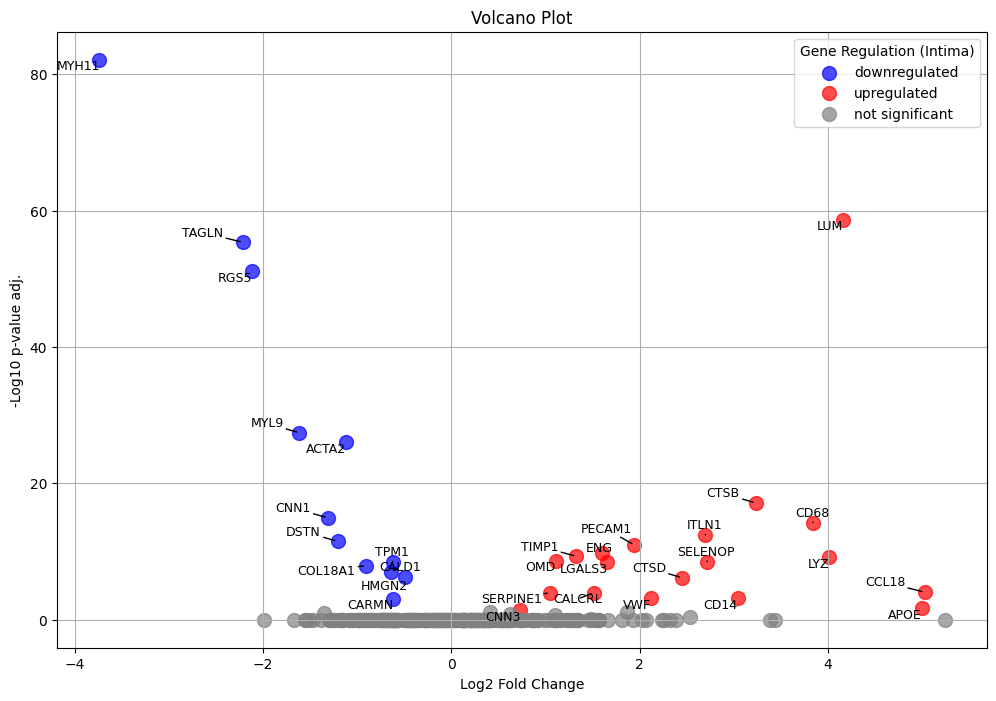

In [21]:
# plt.figure(figsize=(12, 8))
# # Plot the points
# colors = {'blue': 'downregulated', 'red': 'upregulated', 'grey': 'not significant'}
# for color, label in colors.items():
#     subset = df[df['color'] == color]
#     plt.scatter(subset['logfc'], subset['-log10(pvals_adj)'], c=color, label=label, s=100, alpha=0.7, edgecolor=None)

# df_significant = df[df['pvals_adj'] < 0.05]
# texts = []
# for _, row in df_significant.iterrows():
#     texts.append(plt.text(row['logfc'], row['-log10(pvals_adj)'], row['gene'], fontsize=9, ha='right'))

# # Adjust text to avoid overlap
# adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'))

# # Add labels and title
# plt.xlabel('Log2 Fold Change')
# plt.ylabel('-Log10 p-value adj.')
# plt.title('Volcano Plot')
# plt.grid(True)

# plt.legend(title='Gene Regulation (Intima)', loc='upper right')

# # Show the plot
# plt.show()